<a href="https://colab.research.google.com/github/loki20051267/hpc-project/blob/main/paper17_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
S17S1 shape: (9600, 5)
S17S2 shape: (9600, 5)
Columns: ['EEG.AF3', 'EEG.T7', 'EEG.Pz', 'EEG.T8', 'EEG.AF4']
Windowed X shape: (298, 128, 5)
Windowed Y shape: (298,)
Class distribution: [149 149]
Train: (208, 128, 5) (208,)
Val  : (45, 128, 5) (45,)
Test : (45, 128, 5) (45,)
Edge index shape: torch.Size([2, 20])
GNN_LSTM Epoch [1/30] | Train Loss: 0.6953 | Train Acc: 0.5337 | Val Loss: 0.6846 | Val Acc: 0.5778
GNN_LSTM Epoch [2/30] | Train Loss: 0.6899 | Train Acc: 0.5192 | Val Loss: 0.6666 | Val Acc: 0.5778
GNN_LSTM Epoch [3/30] | Train Loss: 0.6832 | Train Acc: 0.5385 | Val Loss: 0.6626 | Val Acc: 0.6889
GNN_LSTM Epoch [4/30] | Train Loss: 0.6712 | Train Acc: 0.6346 | Val Loss: 0.6570 | Val Acc: 0.7333
GNN_LSTM Epoch [5/30] | Train Loss: 0.6621 | Train Acc: 0.5913 | Val Loss: 0.6385 | Val Acc: 0.6889
GNN_LSTM Epoch [6/30] | Train Loss: 0.6449 | Train Acc: 0.6490 | Val Loss: 0.6027 | Val Acc: 0.7111
GNN_LSTM Epoch [7/30] | Train Loss: 0.6042 | Train Acc: 0.6587 | Val

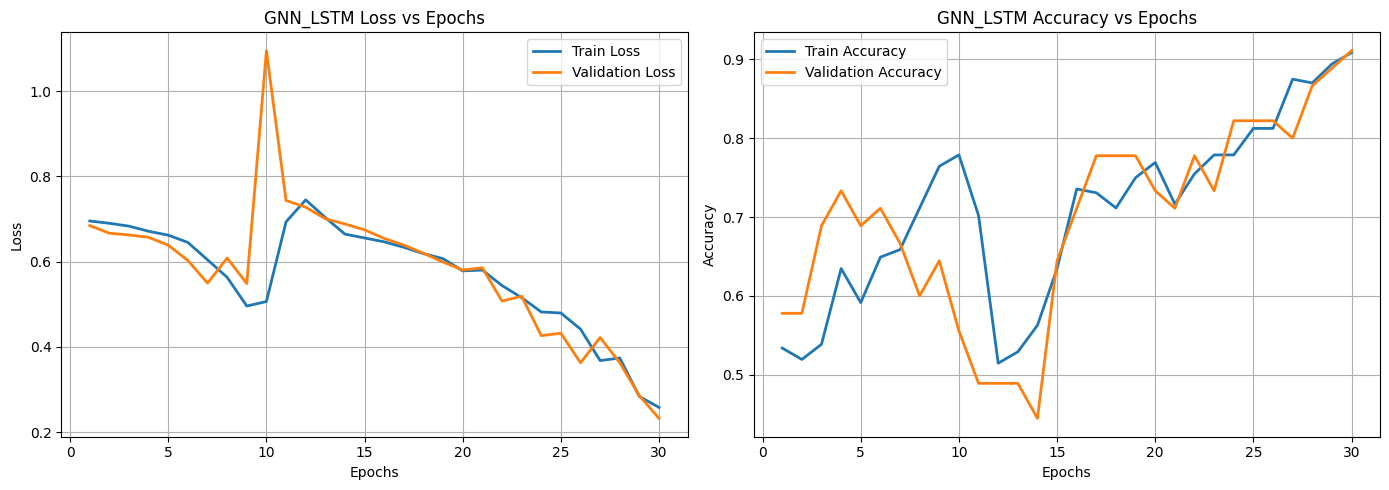

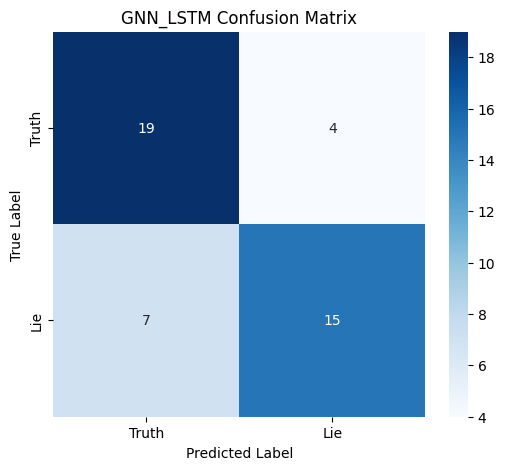

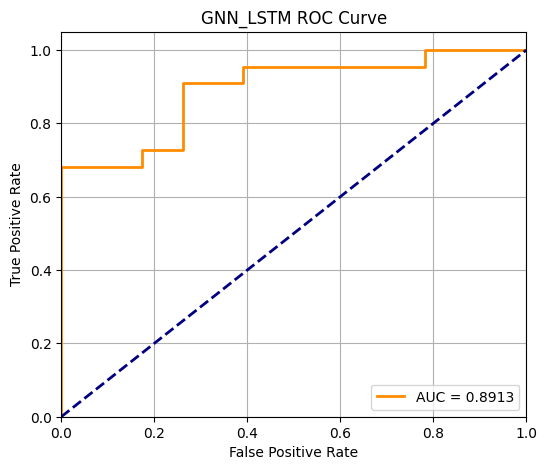

GNN_Transformer Epoch [1/30] | Train Loss: 0.7400 | Train Acc: 0.5433 | Val Loss: 0.7624 | Val Acc: 0.4889
GNN_Transformer Epoch [2/30] | Train Loss: 0.7361 | Train Acc: 0.4952 | Val Loss: 0.6950 | Val Acc: 0.5111
GNN_Transformer Epoch [3/30] | Train Loss: 0.7051 | Train Acc: 0.5337 | Val Loss: 0.6772 | Val Acc: 0.6000
GNN_Transformer Epoch [4/30] | Train Loss: 0.7401 | Train Acc: 0.5096 | Val Loss: 0.6720 | Val Acc: 0.5778
GNN_Transformer Epoch [5/30] | Train Loss: 0.7119 | Train Acc: 0.5529 | Val Loss: 0.6694 | Val Acc: 0.6000
GNN_Transformer Epoch [6/30] | Train Loss: 0.6953 | Train Acc: 0.5481 | Val Loss: 0.6602 | Val Acc: 0.5556
GNN_Transformer Epoch [7/30] | Train Loss: 0.6444 | Train Acc: 0.5865 | Val Loss: 0.6467 | Val Acc: 0.7556
GNN_Transformer Epoch [8/30] | Train Loss: 0.6390 | Train Acc: 0.6394 | Val Loss: 0.6125 | Val Acc: 0.6444
GNN_Transformer Epoch [9/30] | Train Loss: 0.5796 | Train Acc: 0.7019 | Val Loss: 0.5644 | Val Acc: 0.8222
GNN_Transformer Epoch [10/30] | Train

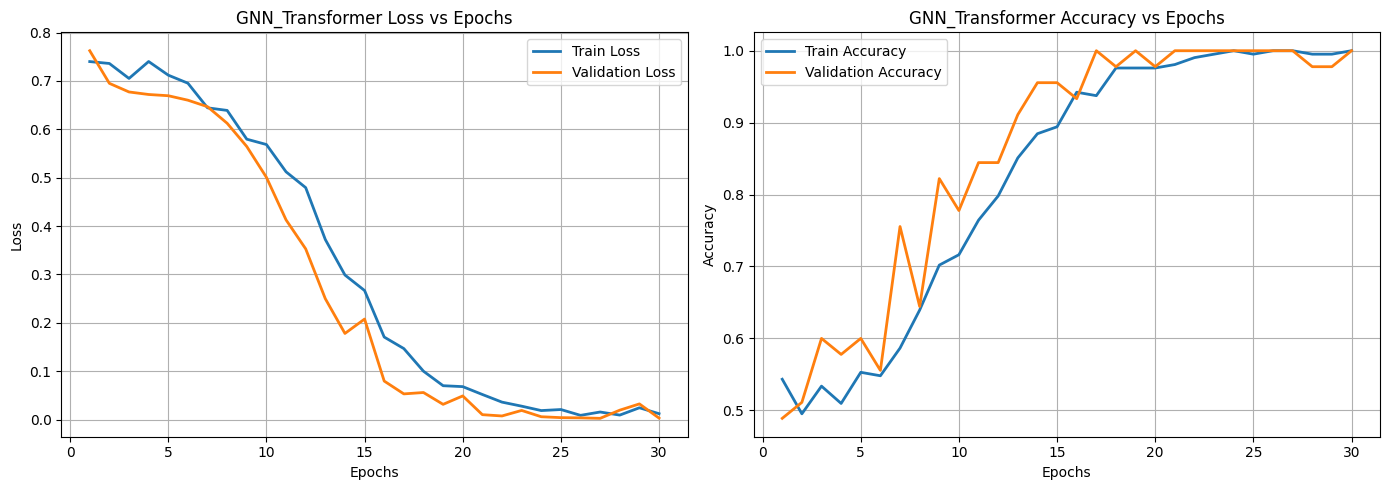

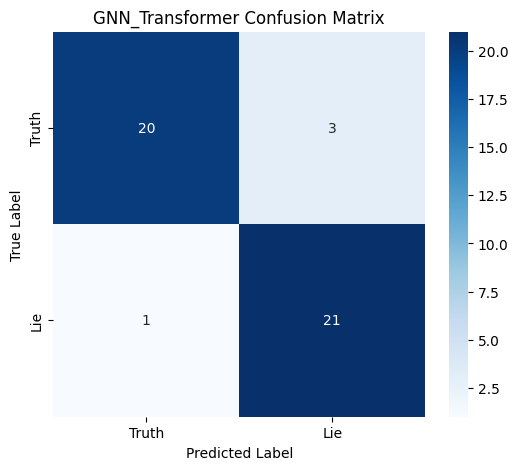

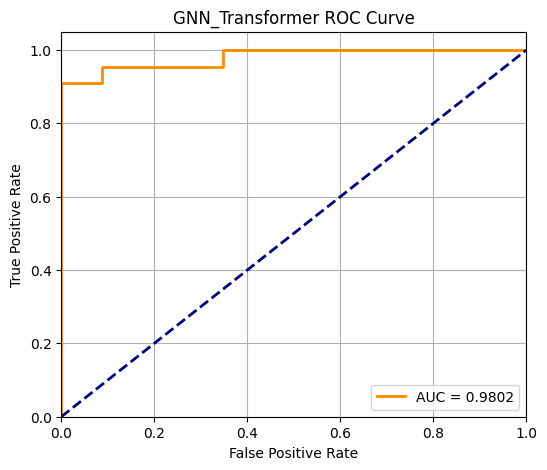


================ FINAL RESULTS ================
GNN_LSTM
Accuracy : 0.7556
Precision: 0.7895
Recall   : 0.6818
F1-score : 0.7317
AUC      : 0.8913

GNN_Transformer
Accuracy : 0.9111
Precision: 0.8750
Recall   : 0.9545
F1-score : 0.9130
AUC      : 0.9802

Best model based on Test Accuracy: GNN_Transformer

If accuracy is not above 95%, try:
1. WINDOW_SIZE = 256
2. STEP_SIZE = 128
3. epochs = 50 or 100
4. gnn_hidden = 32
5. lstm_hidden = 128
6. d_model = 128
7. Add more GraphConv layers
8. Try dropout = 0.2 instead of 0.3
9. Use early stopping
10. Standardize the combined dataset instead of per-file normalization



In [1]:
# ============================================================
# EEG LIE DETECTION USING TEMPORAL GNN
# Models:
#   1) GNN + LSTM
#   2) GNN + Transformer
# Outputs:
#   - Accuracy
#   - Precision / Recall / F1-score
#   - Confusion Matrix
#   - ROC Curve + AUC
#   - Loss vs Epochs
#   - Accuracy vs Epochs
# ============================================================

# =========================
# 1. Install dependencies
# =========================
!pip -q install torch torchvision torchaudio scikit-learn matplotlib seaborn pandas numpy

# =========================
# 2. Imports
# =========================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================
# 3. Reproducibility
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 4. Upload files in Colab
# =========================
# Make sure these two files are uploaded:
# S17S1.csv  -> Truth class (0)
# S17S2.csv  -> Lie class (1)

# =========================
# 5. Load data
# =========================
s1 = pd.read_csv("S17S1.csv")   # truth
s2 = pd.read_csv("S17S2.csv")   # lie

print("S17S1 shape:", s1.shape)
print("S17S2 shape:", s2.shape)
print("Columns:", s1.columns.tolist())

# =========================
# 6. Convert to numpy
# =========================
x1 = s1.values.astype(np.float32)
x2 = s2.values.astype(np.float32)

# =========================
# 7. Normalize each file
# =========================
def normalize(x):
    mean = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True) + 1e-8
    return (x - mean) / std

x1 = normalize(x1)
x2 = normalize(x2)

# labels
y1 = np.zeros(len(x1), dtype=np.int64)  # truth
y2 = np.ones(len(x2), dtype=np.int64)   # lie

# =========================
# 8. Sliding window creation
# =========================
WINDOW_SIZE = 128   # try 256 if needed
STEP_SIZE = 64      # 50% overlap

def create_windows(data, label, window_size=128, step_size=64):
    X, y = [], []
    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        window = data[start:end]              # shape: (T, 5)
        X.append(window)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X1, Y1 = create_windows(x1, 0, WINDOW_SIZE, STEP_SIZE)
X2, Y2 = create_windows(x2, 1, WINDOW_SIZE, STEP_SIZE)

X = np.concatenate([X1, X2], axis=0)
Y = np.concatenate([Y1, Y2], axis=0)

print("Windowed X shape:", X.shape)   # (samples, time_steps, nodes)
print("Windowed Y shape:", Y.shape)
print("Class distribution:", np.bincount(Y))

# =========================
# 9. Train / Validation / Test split
# =========================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

# =========================
# 10. Dataset and DataLoader
# =========================
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, T, 5)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = EEGDataset(X_train, y_train)
val_dataset   = EEGDataset(X_val, y_val)
test_dataset  = EEGDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================
# 11. Graph definition
# 5 EEG channels = 5 nodes
# Fully connected graph without self-loops
# =========================
NUM_NODES = X.shape[2]  # 5

edges = []
for i in range(NUM_NODES):
    for j in range(NUM_NODES):
        if i != j:
            edges.append([i, j])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)
print("Edge index shape:", edge_index.shape)

# =========================
# 12. Simple Graph Convolution
# =========================
class SimpleGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SimpleGraphConv, self).__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        # x: (B, N, F)
        B, N, F = x.shape
        row, col = edge_index
        out = torch.zeros_like(x)

        # neighbor aggregation
        out[:, row, :] += x[:, col, :]
        out = out + x  # self feature

        out = self.linear(out)
        return torch.relu(out)

# =========================
# 13. GNN + LSTM Model
# =========================
class GNN_LSTM(nn.Module):
    def __init__(self, num_nodes=5, gnn_hidden=16, lstm_hidden=64, num_classes=2):
        super(GNN_LSTM, self).__init__()
        self.num_nodes = num_nodes
        self.gnn = SimpleGraphConv(1, gnn_hidden)
        self.lstm = nn.LSTM(
            input_size=num_nodes * gnn_hidden,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x, edge_index):
        # x: (B, T, N)
        B, T, N = x.shape

        # each time step graph: reshape to (B*T, N, 1)
        x = x.reshape(B * T, N, 1)

        gnn_out = self.gnn(x, edge_index)      # (B*T, N, gnn_hidden)
        gnn_out = gnn_out.reshape(B, T, -1)    # (B, T, N*gnn_hidden)

        lstm_out, _ = self.lstm(gnn_out)       # (B, T, lstm_hidden)
        last_hidden = lstm_out[:, -1, :]       # (B, lstm_hidden)

        out = self.dropout(last_hidden)
        logits = self.fc(out)
        return logits

# =========================
# 14. Positional Encoding
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, d_model)
        T = x.size(1)
        return x + self.pe[:, :T, :]

# =========================
# 15. GNN + Transformer Model
# =========================
class GNN_Transformer(nn.Module):
    def __init__(self, num_nodes=5, gnn_hidden=16, d_model=64, nhead=4, num_layers=2, num_classes=2):
        super(GNN_Transformer, self).__init__()
        self.num_nodes = num_nodes
        self.gnn = SimpleGraphConv(1, gnn_hidden)
        self.proj = nn.Linear(num_nodes * gnn_hidden, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=0.3,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x, edge_index):
        # x: (B, T, N)
        B, T, N = x.shape

        x = x.reshape(B * T, N, 1)
        gnn_out = self.gnn(x, edge_index)        # (B*T, N, gnn_hidden)
        gnn_out = gnn_out.reshape(B, T, -1)      # (B, T, N*gnn_hidden)

        z = self.proj(gnn_out)                   # (B, T, d_model)
        z = self.pos_encoder(z)
        z = self.transformer(z)                  # (B, T, d_model)

        pooled = z.mean(dim=1)                   # Global average pooling over time
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits

# =========================
# 16. Training function
# =========================
def train_model(model, train_loader, val_loader, edge_index, epochs=30, lr=1e-3, model_name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_acc = 0.0
    best_model_path = f"{model_name}_best.pth"

    for epoch in range(epochs):
        # training
        model.train()
        running_loss = 0.0
        train_preds_all = []
        train_labels_all = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch, edge_index)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            train_preds_all.extend(preds.detach().cpu().numpy())
            train_labels_all.extend(y_batch.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels_all, train_preds_all)

        # validation
        model.eval()
        val_running_loss = 0.0
        val_preds_all = []
        val_labels_all = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch, edge_index)
                loss = criterion(outputs, y_batch)

                val_running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)

                val_preds_all.extend(preds.detach().cpu().numpy())
                val_labels_all.extend(y_batch.detach().cpu().numpy())

        val_loss = val_running_loss / len(val_loader)
        val_acc = accuracy_score(val_labels_all, val_preds_all)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

        print(f"{model_name} Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    model.load_state_dict(torch.load(best_model_path))
    print(f"Best {model_name} Validation Accuracy: {best_val_acc:.4f}")

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

    return model, history

# =========================
# 17. Evaluation function
# =========================
def evaluate_model(model, test_loader, edge_index, model_name="Model"):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch, edge_index)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"\n{model_name} Test Accuracy   : {acc:.4f}")
    print(f"{model_name} Test Precision  : {prec:.4f}")
    print(f"{model_name} Test Recall     : {rec:.4f}")
    print(f"{model_name} Test F1-score   : {f1:.4f}")

    print(f"\n{model_name} Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))

    cm = confusion_matrix(all_labels, all_preds)

    # ROC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    print(f"{model_name} AUC: {roc_auc:.4f}")

    return {
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
        "cm": cm,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    }

# =========================
# 18. Plot functions
# =========================
def plot_training_history(history, model_name="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    plt.plot(epochs, history["val_loss"], label="Validation Loss", linewidth=2)
    plt.title(f"{model_name} Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy", linewidth=2)
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy", linewidth=2)
    plt.title(f"{model_name} Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, model_name="Model"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Truth", "Lie"],
                yticklabels=["Truth", "Lie"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

def plot_roc_curve(fpr, tpr, roc_auc, model_name="Model"):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# =========================
# 19. Train GNN + LSTM
# =========================
gnn_lstm = GNN_LSTM(num_nodes=NUM_NODES, gnn_hidden=16, lstm_hidden=64, num_classes=2).to(device)
gnn_lstm, history_lstm = train_model(
    gnn_lstm,
    train_loader,
    val_loader,
    edge_index,
    epochs=30,
    lr=1e-3,
    model_name="GNN_LSTM"
)

# =========================
# 20. Evaluate GNN + LSTM
# =========================
results_lstm = evaluate_model(gnn_lstm, test_loader, edge_index, model_name="GNN_LSTM")
plot_training_history(history_lstm, model_name="GNN_LSTM")
plot_confusion_matrix(results_lstm["cm"], model_name="GNN_LSTM")
plot_roc_curve(results_lstm["fpr"], results_lstm["tpr"], results_lstm["auc"], model_name="GNN_LSTM")

# =========================
# 21. Train GNN + Transformer
# =========================
gnn_transformer = GNN_Transformer(
    num_nodes=NUM_NODES,
    gnn_hidden=16,
    d_model=64,
    nhead=4,
    num_layers=2,
    num_classes=2
).to(device)

gnn_transformer, history_transformer = train_model(
    gnn_transformer,
    train_loader,
    val_loader,
    edge_index,
    epochs=30,
    lr=1e-3,
    model_name="GNN_Transformer"
)

# =========================
# 22. Evaluate GNN + Transformer
# =========================
results_transformer = evaluate_model(gnn_transformer, test_loader, edge_index, model_name="GNN_Transformer")
plot_training_history(history_transformer, model_name="GNN_Transformer")
plot_confusion_matrix(results_transformer["cm"], model_name="GNN_Transformer")
plot_roc_curve(results_transformer["fpr"], results_transformer["tpr"], results_transformer["auc"], model_name="GNN_Transformer")

# =========================
# 23. Final comparison
# =========================
print("\n================ FINAL RESULTS ================")
print("GNN_LSTM")
print(f"Accuracy : {results_lstm['accuracy']:.4f}")
print(f"Precision: {results_lstm['precision']:.4f}")
print(f"Recall   : {results_lstm['recall']:.4f}")
print(f"F1-score : {results_lstm['f1']:.4f}")
print(f"AUC      : {results_lstm['auc']:.4f}")

print("\nGNN_Transformer")
print(f"Accuracy : {results_transformer['accuracy']:.4f}")
print(f"Precision: {results_transformer['precision']:.4f}")
print(f"Recall   : {results_transformer['recall']:.4f}")
print(f"F1-score : {results_transformer['f1']:.4f}")
print(f"AUC      : {results_transformer['auc']:.4f}")

better_model = "GNN_LSTM" if results_lstm["accuracy"] > results_transformer["accuracy"] else "GNN_Transformer"
print(f"\nBest model based on Test Accuracy: {better_model}")

# =========================
# 24. Optional tuning tips
# =========================
print("""
If accuracy is not above 95%, try:
1. WINDOW_SIZE = 256
2. STEP_SIZE = 128
3. epochs = 50 or 100
4. gnn_hidden = 32
5. lstm_hidden = 128
6. d_model = 128
7. Add more GraphConv layers
8. Try dropout = 0.2 instead of 0.3
9. Use early stopping
10. Standardize the combined dataset instead of per-file normalization
""")